# Variant Analysis

Understand the behavior hidden inside an XES log before attempting subprocess discovery.

1. How many traces are there?
2. How many activities?
3. How many variants?
4. What are the most common variants?
5. How much behavioral diversity exists?
6. Are there candidate regions that might later become subprocesses?

In [14]:
import pm4py 
import pandas as pd 
from collections import Counter
from pm4py.objects.conversion.log import converter as log_converter


## Load Event Log
Read the repair example XES file and convert it to a PM4Py event log object.

In [15]:
LOG_PATH = "../data/examples/repairExampleCompleteOnly.xes" 
event_log = log_converter.apply(pm4py.read_xes(LOG_PATH) )

parsing log, completed traces ::   0%|          | 0/1000 [00:00<?, ?it/s]

## Basic Statistics
Count the number of traces and unique activities to get an overview of the log.

In [16]:
num_traces = len(event_log) 
activities = set() 
for trace in event_log:
    for event in trace: 
        activities.add(event["concept:name"])
print("Traces:", num_traces) 
print("Unique activities:", len(activities)) 
print("Activities:") 
print(sorted(activities))

Traces: 1000
Unique activities: 8
Activities:
['Analyze Defect', 'Archive Repair', 'Inform User', 'Register', 'Repair (Complex)', 'Repair (Simple)', 'Restart Repair', 'Test Repair']


## Inspect First Trace
Look at the sequence of activities in the first trace to understand the data format.

In [17]:
# Inspect First Trace
first_trace = event_log[0] 
print("Case ID:", first_trace.attributes["concept:name"]) 
for event in first_trace: 
    print(event["concept:name"])

Case ID: 1
Register
Analyze Defect
Repair (Complex)
Test Repair
Inform User
Archive Repair


## Extract Activity Sequences
Convert every trace into a list of activity names for easier analysis.

In [18]:
# Convert Log to Activity Sequences
activity_sequences = []
for trace in event_log:
    sequence = [event["concept:name"] for event in trace]
    activity_sequences.append(sequence)

print(activity_sequences[0])  # Print first sequence

['Register', 'Analyze Defect', 'Repair (Complex)', 'Test Repair', 'Inform User', 'Archive Repair']


## Count Unique Variants
A variant is a unique sequence of activities. Count how many distinct variants exist in the log.

In [19]:
# Compute Variants
variant_counts = Counter(tuple(seq) for seq in activity_sequences)
print(f"Number of unique variants: {len(variant_counts)}")


Number of unique variants: 39


## Top 10 Variants
Print the 10 most frequent variants with their activity sequences and case counts.

In [20]:
# Top 10 Variants
top_variants = variant_counts.most_common(10)
for i, (variant, freq) in enumerate(top_variants, start=1):
    print("=" * 80)
    print(f"Variant {i}")
    print(f"Frequency: {freq}")
    for activity in variant:
        print(" ", activity)

Variant 1
Frequency: 328
  Register
  Analyze Defect
  Inform User
  Repair (Complex)
  Test Repair
  Archive Repair
Variant 2
Frequency: 129
  Register
  Analyze Defect
  Repair (Complex)
  Test Repair
  Inform User
  Archive Repair
Variant 3
Frequency: 103
  Register
  Analyze Defect
  Inform User
  Repair (Simple)
  Test Repair
  Archive Repair
Variant 4
Frequency: 67
  Register
  Analyze Defect
  Repair (Simple)
  Test Repair
  Inform User
  Archive Repair
Variant 5
Frequency: 67
  Register
  Analyze Defect
  Repair (Complex)
  Inform User
  Test Repair
  Archive Repair
Variant 6
Frequency: 41
  Register
  Analyze Defect
  Repair (Simple)
  Inform User
  Test Repair
  Archive Repair
Variant 7
Frequency: 30
  Register
  Analyze Defect
  Repair (Simple)
  Test Repair
  Restart Repair
  Inform User
  Repair (Simple)
  Test Repair
  Archive Repair
Variant 8
Frequency: 21
  Register
  Analyze Defect
  Repair (Simple)
  Test Repair
  Inform User
  Restart Repair
  Repair (Simple)
  Test 

## Variant Coverage
How much of the log do the top variants explain? Cumulative coverage reveals behavioral concentration.

In [21]:
# Variant Coverage
total_cases = len(event_log)
running = 0
for i, (_, freq) in enumerate(top_variants, start=1):
    running += freq
    coverage = running / total_cases
    print(f"Top {i} variants cover {coverage:.2%} of cases")

Top 1 variants cover 32.80% of cases
Top 2 variants cover 45.70% of cases
Top 3 variants cover 56.00% of cases
Top 4 variants cover 62.70% of cases
Top 5 variants cover 69.40% of cases
Top 6 variants cover 73.50% of cases
Top 7 variants cover 76.50% of cases
Top 8 variants cover 78.60% of cases
Top 9 variants cover 80.60% of cases
Top 10 variants cover 82.50% of cases


## Trace Length Distribution
Analyze how long each trace is (in number of events) to understand process complexity.

In [22]:
# Trace Length Distribution
trace_lengths = [
    len(trace)
    for trace in event_log
]

print("Min length:", min(trace_lengths))
print("Max length:", max(trace_lengths))
print("Average length:", sum(trace_lengths)/len(trace_lengths))

Min length: 6
Max length: 15
Average length: 7.107


## Activity Frequency
Count how many times each activity appears across the entire log.

In [23]:
# Most Frequent Activities
activity_freq = Counter(event["concept:name"] for trace in event_log for event in trace)
print("Most common activities:")
for activity, freq in activity_freq.most_common(10):
    print(f"  {activity}: {freq} occurrences")

Most common activities:
  Test Repair: 1369 occurrences
  Register: 1000 occurrences
  Analyze Defect: 1000 occurrences
  Inform User: 1000 occurrences
  Archive Repair: 1000 occurrences
  Repair (Simple): 697 occurrences
  Repair (Complex): 672 occurrences
  Restart Repair: 369 occurrences


## Directly-Follows Graph
Count how often each activity is directly followed by another. This reveals branching and sequential patterns.

In [24]:
# Directly-Follows Relationships. This immediately reveals branching.
dfg_counter = Counter() 
for trace in activity_sequences: 
    for i in range(len(trace)-1): 
        pair = ( trace[i], trace[i+1] ) 
        dfg_counter[pair] += 1 
for edge, freq in dfg_counter.most_common(20): 
    print(edge, freq)

('Register', 'Analyze Defect') 1000
('Test Repair', 'Archive Repair') 795
('Repair (Simple)', 'Test Repair') 603
('Repair (Complex)', 'Test Repair') 597
('Analyze Defect', 'Inform User') 499
('Inform User', 'Repair (Complex)') 371
('Test Repair', 'Restart Repair') 307
('Analyze Defect', 'Repair (Simple)') 278
('Test Repair', 'Inform User') 267
('Restart Repair', 'Repair (Simple)') 226
('Analyze Defect', 'Repair (Complex)') 223
('Inform User', 'Archive Repair') 205
('Inform User', 'Repair (Simple)') 193
('Inform User', 'Test Repair') 169
('Repair (Simple)', 'Inform User') 94
('Restart Repair', 'Repair (Complex)') 78
('Repair (Complex)', 'Inform User') 75
('Restart Repair', 'Inform User') 65
('Inform User', 'Restart Repair') 62


## Variation Points
Identify activities that can be followed by multiple different activities — these are decision points in the process.

In [25]:
# Identify Candidate Variation Points
successors = {} 
for trace in activity_sequences: 
    for i in range(len(trace)-1): 
        current = trace[i] 
        nxt = trace[i+1] 
        successors.setdefault( current, set() ).add(nxt) 
for activity, next_activities in successors.items(): 
    if len(next_activities) > 1: 
        print(activity) 
        print(" ->", next_activities)

Analyze Defect
 -> {'Inform User', 'Repair (Complex)', 'Repair (Simple)'}
Repair (Complex)
 -> {'Inform User', 'Test Repair'}
Test Repair
 -> {'Inform User', 'Restart Repair', 'Archive Repair'}
Inform User
 -> {'Restart Repair', 'Test Repair', 'Repair (Simple)', 'Archive Repair', 'Repair (Complex)'}
Repair (Simple)
 -> {'Inform User', 'Test Repair'}
Restart Repair
 -> {'Inform User', 'Repair (Complex)', 'Repair (Simple)'}


## Visualize DFG with PM4Py
Render the full directly-follows graph with frequency annotations.

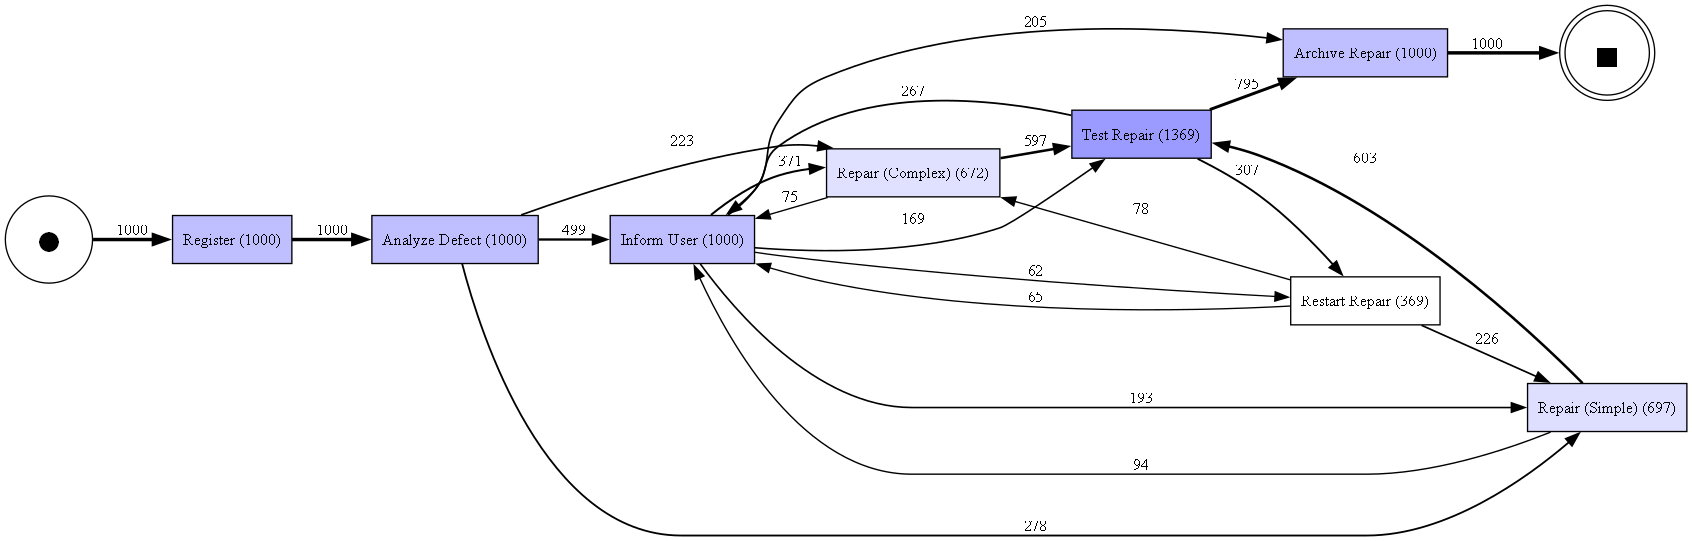

In [26]:
from pm4py.visualization.dfg import visualizer as dfg_visualizer

dfg, start_activities, end_activities = pm4py.discover_dfg(event_log)

gviz = dfg_visualizer.apply(
    dfg,
    variant=dfg_visualizer.Variants.FREQUENCY,
    parameters={
        dfg_visualizer.Variants.FREQUENCY.value.Parameters.FORMAT: "png",
        "start_activities": start_activities,
        "end_activities": end_activities,
    },
)
dfg_visualizer.view(gviz)